# ```thinst``` : thin data spatiotemporally

## Setup

### Get thinst

#### Install thinst (if not already installed)
Uncomment and run the cell below to install ```thinst``` if it has not already been installed. This exemplar also requires ```numpy``` and ```pandas``` to be installed.

In [1]:
# %pip install thinst
# %pip install numpy
# %pip install pandas

#### Import thinst (as well as numpy and pandas)

In [2]:
from thinst import thinst  # import the thinst function (the main thinning function)
from thinst.plots import *  # import additional plotting functions
import numpy as np
import pandas as pd

#### Interactive plots
We run the cell below to make the plots interactive. We can then use the hover buttons on the top left of the plots to zoom in and pan around. We can also resize the images by clicking and dragging the bottom right corner.

In [3]:
%matplotlib widget

### Thinning parameters
Before thinning the data, we set a spatial and temporal threshold to use for thinning. Additionally, we set the unit of the temporal threshold.
<br>In our example, we set the spatial threshold to 10000 metres and the temporal threshold to 30 days.

In [4]:
spatial_threshold = 10000
temporal_threshold = 30
temporal_unit = 'day'

### Samples

#### Make sample dataset
For the purposes of this exemplar, we randomly generate 50 points spread across two spatial axes (x and y) and a temporal axis (z).
<br>The resulting points are stored in a ```pandas.DataFrame``` with a column for the coordinates and a column for the datetimes. This is the recommended format for data input to ```thinst```, although it is also possible to have the coordinates and datetimes in separate ```lists``` or ```pandas.Series```.

In [5]:
sample_size = 50  # set sample size

x_min, x_max = 0, 100000  # set spatial limits (x axis)
y_min, y_max = 0, 100000  # set spatial limits (y axis)
z_min, z_max = pd.to_datetime('2020-01-01 00:00:00'), pd.to_datetime('2022-12-31 23:59:59')  # set temporal limits (z axis)

random_xs = np.random.uniform(x_min, x_max, size=sample_size)  # generate random x coordinates
random_ys = np.random.uniform(y_min, y_max, size=sample_size)  # generate random y coordinates
random_xys = [(x, y) for x, y in zip(random_xs, random_ys)]  # combine random x and y coordinates
random_zs = [pd.to_datetime(int(r), unit='s') for r in np.random.uniform(low=z_min.timestamp(), high=z_max.timestamp(), size=sample_size)]  # generate random datetimes (i.e., Z values)

samples = pd.DataFrame({'coords_col': random_xys, 'datetimes_col': random_zs})  # DataFrame of the random points
samples = samples.sort_values('datetimes_col').reset_index(drop=True)  # sort by datetime

#### View the sample dataset
Before thinning, we can view the sample dataset in various ways...

##### As a DataFrame
Firstly, we print the first and last rows of the samples DataFrame.
<br>Note that there are two columns (```coords_col``` and ```datetimes_col```) and that the indices (on the left of the table) go from 0 to 49.

In [6]:
print(samples[:5])
print(samples[45:])

                                coords_col       datetimes_col
0   (6609.018703158431, 53640.25830559105) 2020-01-13 06:09:25
1  (70553.38236299809, 28344.048121651933) 2020-01-14 13:19:48
2   (99481.92606447311, 39543.18995368425) 2020-02-04 04:27:54
3   (60139.77102477453, 36928.62719556424) 2020-02-05 13:33:33
4   (70645.74749246243, 61075.62885888509) 2020-02-09 07:01:50
                                  coords_col       datetimes_col
45     (91390.7829915499, 7904.618178752554) 2022-07-10 19:06:58
46     (74130.46241645498, 5941.42840262396) 2022-07-25 10:41:37
47    (47157.61440193465, 88381.64825368617) 2022-07-29 02:12:44
48    (2124.018368682068, 14121.73932292876) 2022-09-02 03:45:56
49  (18760.573322833752, 29069.568739966533) 2022-10-08 09:02:26


##### As a spatial plot
Secondly, we plot the samples spatially as dots. Each dot has a pale circle around it whose diameter is equal to the spatial threshold.
<br>Accordingly, if two circles overlap, then their corresponding points are within the spatial threshold of each other.

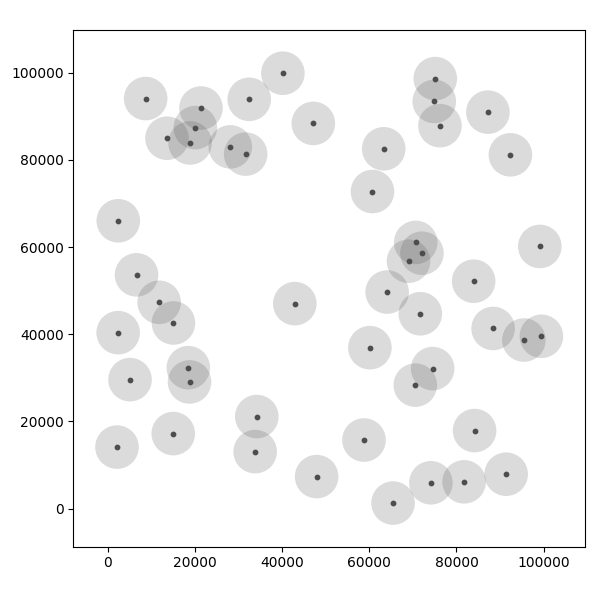

In [7]:
plot_sp(df=samples, coords='coords_col', sp_threshold=spatial_threshold)

#### As a temporal plot 
Finally, we plot the samples temporally as dots. Each dot has a pale line centred around it whose length is equal to the temporal threshold.
<br>Accordingly, if two lines overlap horizontally (in the sense that the right end of a line extends past the left end of the next), then their corresponding points are within the temporal threshold of each other..
<br>*Please note: the y axis is meaningless and serves only to space the dots.

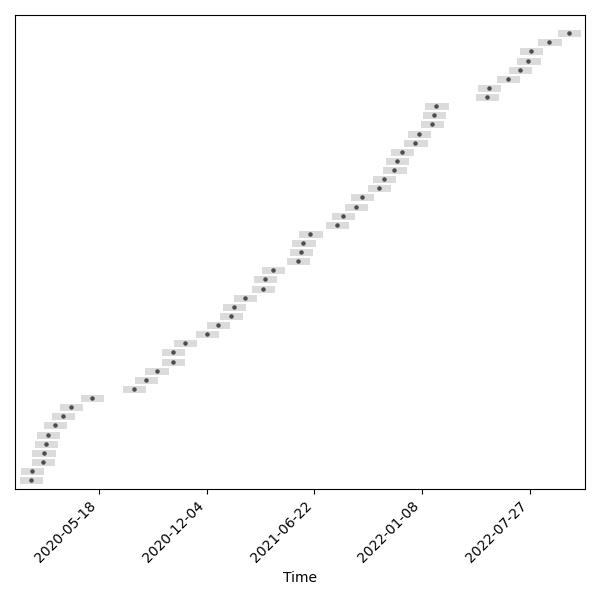

In [8]:
plot_tm(df=samples, datetimes='datetimes_col', tm_threshold=temporal_threshold, tm_unit=temporal_unit)

## Thinning
Now that we've set up our sample dataset and parameters, we can begin to thin.
<br>For the purpose of explanation, this exemplar includes a spatial thin, a temporal thin, and a spatiotemporal thin. Normally, however, we would only conduct one.

### Spatial thin
Here, we conduct a spatial only thin.
<br>To do so, we use the ```thinst``` function and input the ```samples``` DataFrame that we made before as well as the name of the column containing the coordinates: ```coords_col```.
<br>Additionally, we specify the spatial threshold as the value that we set before with the variable ```spatial_threshold```.
<br>Note that we don't explicitly state that we want to do spatial thinning. Instead, because we only specify a spatial threshold, ```thinst``` deduces that this is what we want to do.

In [9]:
samples_kept = thinst(
    df=samples,  # the sample DataFrame
    coords='coords_col',  # the name of the column containing the coordinates
    sp_threshold=spatial_threshold)  # the spatial threshold

The resulting DataFrame (```samples_kept```) contains only those points that were kept after thinning. 
<br>Below, we print the first ten rows as well as the number of samples kept.
<br>Note that some of the indices (on the left of the table) are not there as they were removed during thinning.

In [10]:
print(samples_kept[:10])
print(f'\nNumber of samples: {len(samples_kept)}')

                                  coords_col       datetimes_col
0     (6609.018703158431, 53640.25830559105) 2020-01-13 06:09:25
1    (70553.38236299809, 28344.048121651933) 2020-01-14 13:19:48
2     (99481.92606447311, 39543.18995368425) 2020-02-04 04:27:54
3     (60139.77102477453, 36928.62719556424) 2020-02-05 13:33:33
6     (21387.263964597092, 91908.1857883765) 2020-02-27 17:50:53
9    (42910.96744429666, 47035.485440395096) 2020-05-05 12:50:55
11   (84153.46305808311, 17915.094838285728) 2020-08-13 12:14:18
12  (15028.608943438181, 17226.084254604702) 2020-09-02 21:28:43
15   (65445.95985447252, 1284.4854142528118) 2020-10-25 23:11:54
17     (63310.43137607427, 82552.3926425862) 2020-12-25 08:32:10

Number of samples: 35


Below, we plot the points kept after spatial thinning.
<br>Note that none of the circles overlap (in contrast to when we plotted the full sample dataset before).

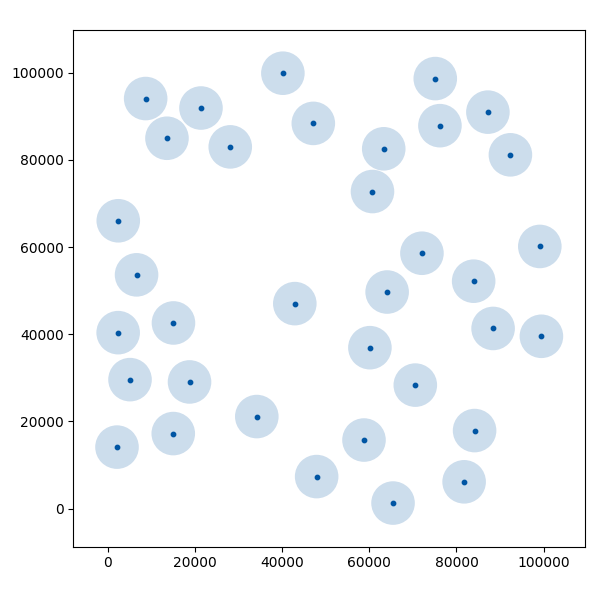

In [11]:
plot_sp(df=samples_kept, coords='coords_col', sp_threshold=spatial_threshold, colour='#0055a3')

For the sake of comparison, we can also get those datapoints that were removed with the following code.

In [12]:
samples_removed = samples.copy().loc[~samples.index.isin(samples_kept.index)]

Below, we plot both the points kept after spatial thinning (blue) and those removed after spatial thinning (yellow).
<br>Note that all the yellow circles (those of the removed points) overlap with one or more other circles (blue or yellow).

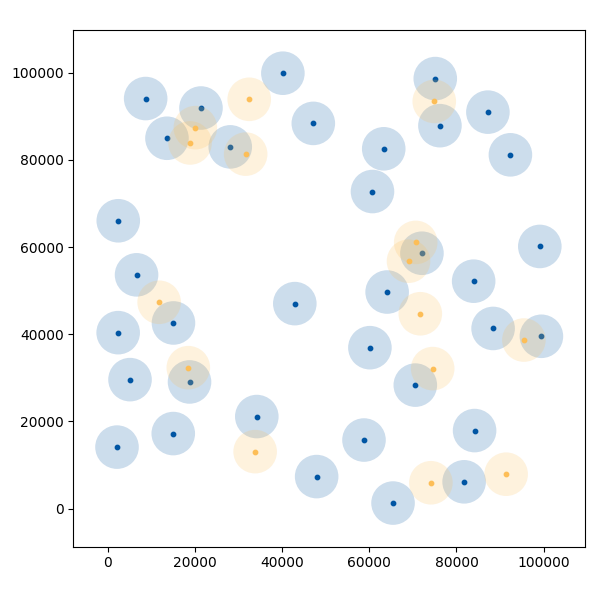

In [13]:
plot_sp_thinned(df_kept=samples_kept, coords_kept='coords_col', df_removed=samples_removed, coords_removed='coords_col', sp_threshold=spatial_threshold)

### Temporal thin
Here, we conduct a temporal only thin.
<br>To do so, we use the ```thinst``` function and input the ```samples``` DataFrame that we made before as well as the name of the column containing the datetimes: ```datetimes_col```.
<br>Additionally, we specify the temporal threshold and the temporal units as the values that we set before with the variables ```temporal_threshold``` and ```temporal_unit```, respectively.
<br>Note that we don't explicitly state that we want to do temporal thinning. Instead, because we only specify a temporal threshold, ```thinst``` deduces that this is what we want to do.

In [14]:
samples_kept = thinst(
    df=samples, # the sample DataFrame
    datetimes='datetimes_col',  # the name of the column containing the datetimes
    tm_threshold=temporal_threshold,  # the temporal threshold
    tm_unit=temporal_unit)  # the temporal units

The resulting DataFrame (```samples_kept```) contains only those points that were kept after thinning. 
<br>Below, we print the first ten rows as well as the number of samples kept.
<br>Note that some of the indices (on the left of the table) are not there as they were removed during thinning.

In [15]:
print(samples_kept[:10])
print(f'\nNumber of samples: {len(samples_kept)}')

                                  coords_col       datetimes_col
0     (6609.018703158431, 53640.25830559105) 2020-01-13 06:09:25
5    (20092.206570074744, 87408.55679165249) 2020-02-13 19:01:06
8     (74903.81831182774, 93421.46088576008) 2020-03-27 12:30:11
9    (42910.96744429666, 47035.485440395096) 2020-05-05 12:50:55
10    (74539.78051313688, 32129.09960138536) 2020-07-22 21:33:13
12  (15028.608943438181, 17226.084254604702) 2020-09-02 21:28:43
15   (65445.95985447252, 1284.4854142528118) 2020-10-25 23:11:54
16   (11794.504803318661, 47343.27425314524) 2020-12-04 14:03:56
20   (95463.58744886954, 38683.057021626955) 2021-02-13 13:53:27
23    (2414.716898025615, 66043.02073938526) 2021-04-06 03:40:30

Number of samples: 22


Below, we plot the points kept after temporal thinning.
<br>Note that none of the lines overlap horizontally (in contrast to when we plotted the full sample dataset before).
<br>*Please note: if some lines appear to overlap, zoom in on the plot with the zoom tool (hover button over the top left of the plot) to see that they do not actually overlap, they simply appear to due to the rendering of the image.

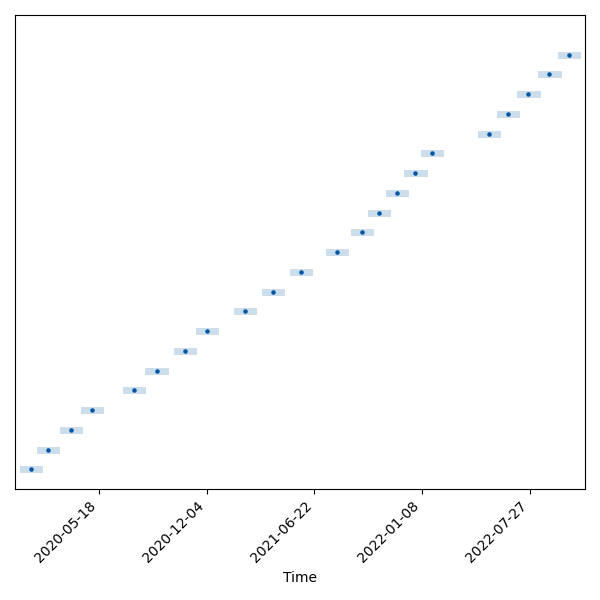

In [16]:
plot_tm(df=samples_kept.sort_values(by='datetimes_col'), datetimes='datetimes_col', tm_threshold=temporal_threshold, tm_unit=temporal_unit, colour='#0055a3')

For the sake of comparison, we can also get those datapoints that were removed with the following code.

In [17]:
samples_removed = samples.copy().loc[~samples.index.isin(samples_kept.index)]

Below, we plot both the points kept after temporal thinning (blue) and those removed after temporal thinning (yellow).
<br>Note that the yellow lines (those of the removed points) overlap with one or more other lines (blue or yellow).

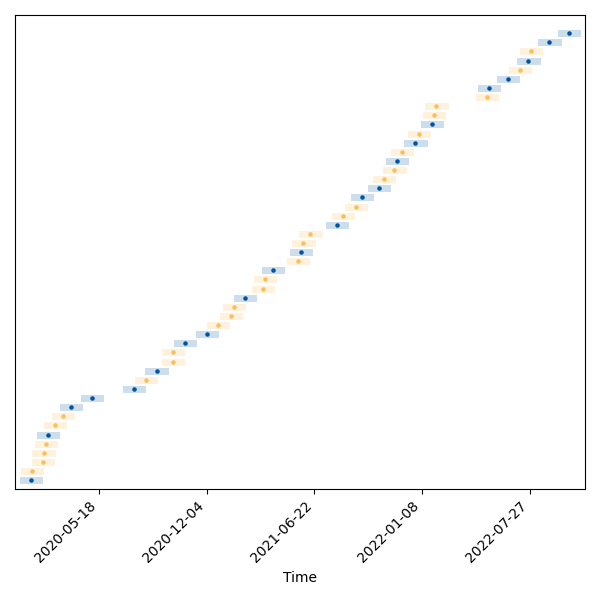

In [18]:
plot_tm_thinned(df_kept=samples_kept, datetimes_kept='datetimes_col', df_removed=samples_removed, datetimes_removed='datetimes_col', tm_threshold=temporal_threshold, tm_unit=temporal_unit)

### Spatiotemporal thin
Here, we conduct a spatiotemporal thin.
<br>To do so, we use the ```thinst``` function and input the ```samples``` DataFrame that we made before as well as the names of the columns containing the coordinates and the datetimes: ```coords_col``` and ```datetimes_col```, respectively.
<br>Additionally, we specify the spatial threshold, the temporal threshold, and the temporal units as the values that we set before with the variables ```spatial_threshold```, ```temporal_threshold```, and ```temporal_unit```, respectively.
<br>Note that we don't explicitly state that we want to do spatiotemporal thinning. Instead, because we specify both a spatial threshold and a temporal threshold, ```thinst``` deduces that this is what we want to do.

In [19]:
samples_kept = thinst(
    df=samples, # the sample DataFrame
    coords='coords_col',  # the name of the column containing the coordinates
    sp_threshold=spatial_threshold,  # the spatial threshold
    datetimes='datetimes_col',  # the name of the column containing the datetimes
    tm_threshold=temporal_threshold,  # the temporal threshold
    tm_unit=temporal_unit)  # the temporal units

The resulting DataFrame (```samples_kept```) contains only those points that were kept after thinning. 
<br>Below, we print the first ten rows as well as the number of samples kept.
<br>Note that some of the indices (on the left of the table) are not there as they were removed during thinning.

In [20]:
print(samples_kept[:10])
print(f'\nNumber of samples: {len(samples_kept)}')

                                 coords_col       datetimes_col
0    (6609.018703158431, 53640.25830559105) 2020-01-13 06:09:25
1   (70553.38236299809, 28344.048121651933) 2020-01-14 13:19:48
2    (99481.92606447311, 39543.18995368425) 2020-02-04 04:27:54
3    (60139.77102477453, 36928.62719556424) 2020-02-05 13:33:33
4    (70645.74749246243, 61075.62885888509) 2020-02-09 07:01:50
5   (20092.206570074744, 87408.55679165249) 2020-02-13 19:01:06
7     (32456.0521486424, 93907.05940441684) 2020-03-12 15:25:15
8    (74903.81831182774, 93421.46088576008) 2020-03-27 12:30:11
9   (42910.96744429666, 47035.485440395096) 2020-05-05 12:50:55
10   (74539.78051313688, 32129.09960138536) 2020-07-22 21:33:13

Number of samples: 49


Below, we spatially plot the points kept after spatiotemporal thinning.
<br>Note that some of the circles may overlap. This is okay as long as they don't also overlap temporally.

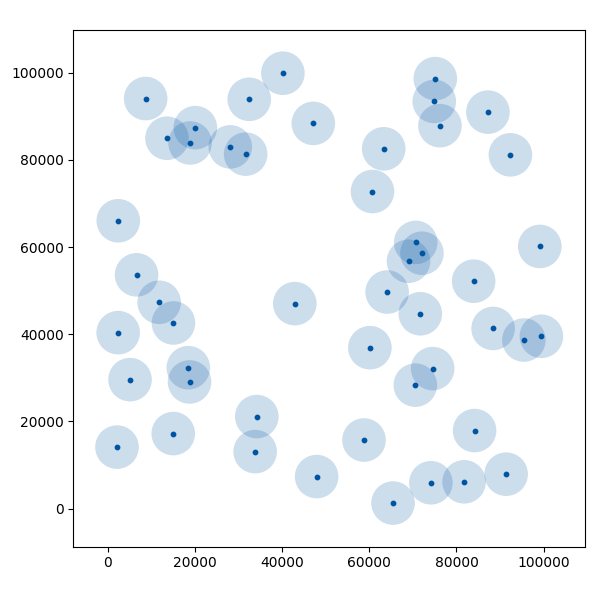

In [21]:
plot_sp(df=samples_kept, coords='coords_col', sp_threshold=spatial_threshold, colour='#0055a3')

Below, we temporally plot the points kept after spatiotemporal thinning.
<br>Note that some of the lines may overlap. This is okay as long as they don't also overlap spatially.

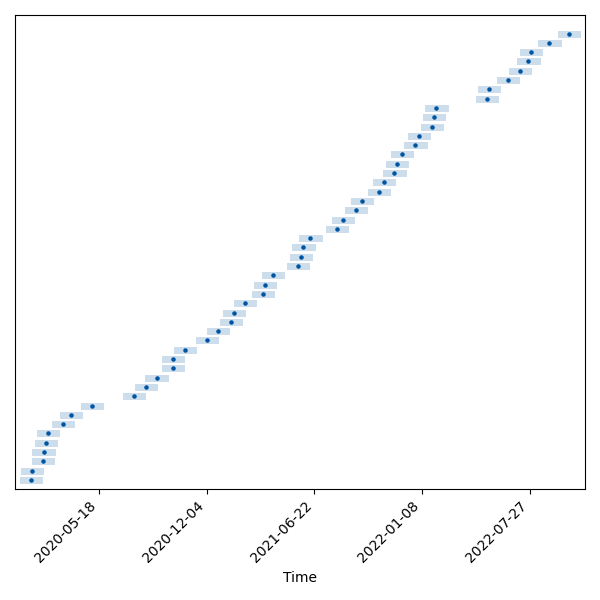

In [22]:
plot_tm(df=samples_kept, datetimes='datetimes_col', tm_threshold=temporal_threshold, tm_unit=temporal_unit, colour='#0055a3')

To illustrate that no two points overlap spatially _and_ temporally, we can make an additional plot of datapoints that were kept after thinning as cylinders with the spatial threshold illustrated by the diameter (x and y axes) and the temporal threshold illustrated by the height (z axis).
<br>We can rotate the plot around to see that no two cylinders overlap.
<br>Please note: Depending on the software that this plot is run in, it may be interactive and able to be rotated. Additionally, the interactive plot will be slow if the number of points is >50

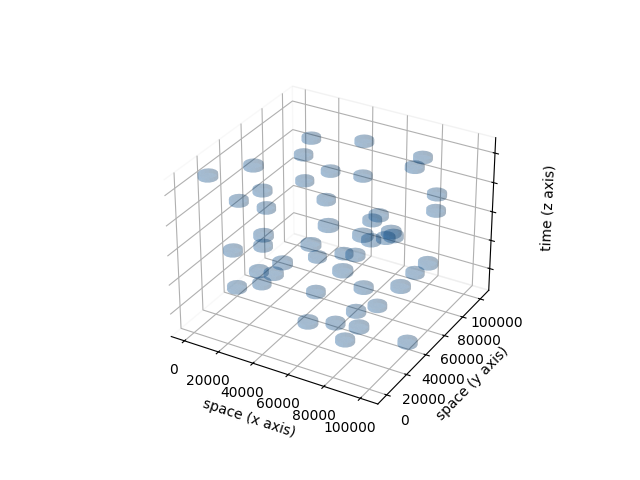

In [23]:
plot_sptm(df=samples_kept, coords='coords_col', sp_threshold=spatial_threshold, datetimes='datetimes_col', tm_threshold=temporal_threshold, tm_unit=temporal_unit, colour='#0055a3')